In [ ]:
import os
import glob
import pandas as pd
from tqdm import tqdm

input_dir = "./outputs/harmonization/"

search_pattern = os.path.join(input_dir, "**", "*radiomics.csv")
csv_files = glob.glob(search_pattern, recursive=True)

assert csv_files, "Aucun fichier CSV de radiomiques trouvé dans le répertoire spécifié."
    
print(f"📄 {len(csv_files)} fichiers trouvés. Début de la lecture...")

df_list = []
for file_path in tqdm(csv_files, desc="Lecture ..."):
    df = pd.read_csv(file_path)
    
    if df.empty: 
        continue
    
    parts = os.path.normpath(file_path).split(os.sep)
    
    # structure du dossier output que j'ai préalablement définie
    if len(parts) >= 4:
        domain = parts[ -4 ]
        
        if "_to_" in domain: # stargan
            domain_source, domain_target = domain.split("_to_", 1)
        else: # harmonisation std
            domain_source, domain_target = domain, None
            
        # Insertion des métadonnées contextuelles au début du DataFrame
        df.insert(0, 'Domain_Target', domain_target)
        df.insert(0, 'Domain_Source', domain_source)
        df.insert(0, 'Domain', domain)
    else:
        df.insert(0, 'Source_Path', os.path.dirname(file_path))
    
    df_list.append(df)
        

assert df_list, "Aucun DataFrame valide n'a été créé à partir des fichiers CSV"

print("🔗 Concaténation des DataFrames...")
master_df = pd.concat(df_list, ignore_index=True)

print("="*50)
print("✅ FUSION TERMINÉE AVEC SUCCÈS")
print("="*50)
print(f"Total des lignes  : {len(master_df)}")
print(f"Total des colonnes: {len(master_df.columns)}")
print("="*50)

# master_df.head()

save_path = 'data/master_radiomics.csv'
master_df.to_csv(save_path, index=False)
print(f"💾 DataFrame fusionné sauvegardé sous : {save_path}")

📄 375 fichiers trouvés. Début de la lecture...


Lecture ...: 100%|██████████| 375/375 [00:01<00:00, 350.29it/s]

🔗 Concaténation des DataFrames...
✅ FUSION TERMINÉE AVEC SUCCÈS
Total des lignes  : 750
Total des colonnes: 101


,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,original_firstorder_90Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,nantes,nantes,None,15080000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,1.911459,2.212969,...,62.775699,0.159397,0.004766,0.039991,0.000861,29.159120,0.002887,1.284328,0.011256,0.015626
1,nantes,nantes,None,15080000,liver,standard,source_cropped.nii.gz,Sphere_20.0mm,2.178105,2.912618,...,6.201635,0.059041,0.024455,0.624618,0.002068,8.223947,0.002482,17.024284,0.018902,0.071017
2,nantes,nantes,None,13250000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,1.526373,1.800982,...,104.608591,0.266349,0.004306,0.023994,0.001395,35.651290,0.002899,1.261954,0.008647,0.016329
3,nantes,nantes,None,13250000,liver,standard,source_cropped.nii.gz,Sphere_20.0mm,1.399582,1.906235,...,11.923378,0.070047,0.017445,0.333323,0.001760,12.458307,0.002309,8.385329,0.014138,0.039566
4,nantes,nantes,None,8280000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,2.363982,2.765342,...,26.326924,0.080954,0.006327,0.086382,0.000717,18.197376,0.002652,2.897425,0.012243,0.028398


In [37]:
# read csv
import pandas as pd
master_df = pd.read_csv('./master_radiomics.csv')
master_df.head(5)

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,nantes,nantes,NaN,15080000,liver,NaN,earl2,earl2.nii.gz,Sphere_20.0mm,2.296872,...,19.661843,0.090656,0.009246,0.141625,0.000970,15.596561,0.002520,4.752409,0.013516,0.032527
1,nantes,nantes,NaN,15080000,liver,NaN,gaussian-earl2,gaussian-earl2.nii.gz,Sphere_20.0mm,2.409533,...,67.157445,0.160913,0.003982,0.028922,0.000726,24.849698,0.003068,1.112908,0.006622,0.017796
2,nantes,nantes,NaN,15080000,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.178105,...,6.201635,0.059041,0.024455,0.624618,0.002068,8.223947,0.002482,17.024284,0.018902,0.071017
3,nantes,nantes,NaN,15080000,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,1.919651,...,66.037204,0.149348,0.003760,0.035986,0.000583,13.307441,0.004121,1.556828,0.004559,0.038818
4,nantes,nantes,NaN,13250000,liver,NaN,earl2,earl2.nii.gz,Sphere_20.0mm,1.483039,...,38.439752,0.119991,0.006826,0.076435,0.000880,21.325062,0.002418,2.749377,0.008279,0.021498


In [38]:
import pandas as pd

req_mods = ['pet', 'harmonized-pet-vae', 'harmonized-pet-standard-vae', 'gaussian-earl1']

df_filtered = master_df[master_df['Modality'].isin(req_mods)]

mod_counts = df_filtered.groupby('Subject_ID')['Modality'].nunique()
valid_patients = mod_counts[mod_counts == len(req_mods)].index

master_df = df_filtered[df_filtered['Subject_ID'].isin(valid_patients)]
master_df

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
407,rennes,rennes,NaN,Piph5SiyBhRTMvGS6WNkKD,liver,NaN,harmonized-pet-standard-vae,harmonized-pet-standard-vae.nii.gz,Sphere_20.0mm,2.062039,...,8.907918,0.048557,0.009408,0.258699,0.000677,5.186730,0.003460,11.066281,0.012980,0.109598
408,rennes,rennes,NaN,Piph5SiyBhRTMvGS6WNkKD,liver,NaN,gaussian-earl1,gaussian-earl1.nii.gz,Sphere_20.0mm,2.338092,...,72.906727,0.192894,0.004224,0.031578,0.000913,33.200501,0.003049,1.231739,0.014444,0.015719
410,rennes,rennes,NaN,Piph5SiyBhRTMvGS6WNkKD,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.116253,...,8.291408,0.063648,0.019061,0.531596,0.001550,5.942943,0.003174,17.968896,0.015588,0.126274
411,rennes,rennes,NaN,Piph5SiyBhRTMvGS6WNkKD,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,2.030314,...,35.996515,0.097739,0.005437,0.068958,0.000660,17.400303,0.002939,2.301830,0.008985,0.029188
416,rennes,rennes,NaN,Y89iNoWEoRWohbsz5B3vWH,liver,NaN,harmonized-pet-standard-vae,harmonized-pet-standard-vae.nii.gz,Sphere_20.0mm,2.281566,...,21.369816,0.089810,0.009534,0.160378,0.001030,11.223359,0.002957,6.240263,0.012342,0.054856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2865,chb,chb,NaN,9401162139m,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,0.997036,...,140.303490,0.304826,0.003281,0.017316,0.001010,25.197046,0.004128,0.893756,0.005728,0.024513
3151,chb,chb,NaN,9401172523m,liver,NaN,harmonized-pet-standard-vae,harmonized-pet-standard-vae.nii.gz,Sphere_20.0mm,2.010402,...,105.508860,0.276050,0.004299,0.022004,0.001571,37.873551,0.003042,1.233674,0.012135,0.016443
3152,chb,chb,NaN,9401172523m,liver,NaN,gaussian-earl1,gaussian-earl1.nii.gz,Sphere_20.0mm,2.072162,...,105.002205,0.218208,0.003474,0.021399,0.000759,24.014337,0.004192,0.822687,0.004761,0.024423
3154,chb,chb,NaN,9401172523m,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.982684,...,32.647239,0.108156,0.006038,0.073909,0.000753,15.807750,0.002768,4.041563,0.010069,0.038616


## Kruskall-Wallis Test

In [40]:
import pandas as pd
from scipy.stats import kruskal

df_std = master_df[master_df['Modality'] == 'pet'].copy()
df_harm = master_df[master_df['Modality'] == 'gaussian-earl1'].copy()

domains_list = list(master_df['Domain_Source'].dropna().unique())

results = []
features = [col for col in master_df.columns if col.startswith('original_') and not col.startswith('original_shape_')]

print(f"🚀 Audit d'harmonisation sur {len(features)} features")
print(f"Centres comparés : {domains_list}")

for feat in features:
    groups_std = [df_std[df_std['Domain_Source'] == d][feat].dropna().values for d in domains_list]
    groups_harm = [df_harm[df_harm['Domain_Source'] == d][feat].dropna().values for d in domains_list]
    
    if all(len(g) > 0 for g in groups_std) and all(len(g) > 0 for g in groups_harm):
        # Kruskal-Wallis pour mesurer l'écart inter-centres
        h_std, p_std = kruskal(*groups_std)
        h_harm, p_harm = kruskal(*groups_harm)
        
        # Calcul de l'amélioration (pourcentage de réduction de la stat H)
        if h_std > 0:
            improvement_pct = ((h_std - h_harm) / h_std) * 100
        else:
            improvement_pct = 0.0
            
        results.append({
            'Feature': feat,
            'H_Standard (Biais)': round(h_std, 1),
            'H_Harmonized (Biais)': round(h_harm, 1),
            'Amélioration (%)': round(improvement_pct, 1)
        })

kw_results = pd.DataFrame(results)
total_features = len(kw_results)

if total_features > 0:
    improved_features = len(kw_results[kw_results['Amélioration (%)'] > 0])
    worsened_features = total_features - improved_features

    print("\n" + "="*60)
    print("📈 BILAN GLOBAL DE L'HARMONISATION")
    print("="*60)
    print(f"✔️ Features améliorées (Biais réduit) : {improved_features} / {total_features} ({(improved_features/total_features)*100:.1f}%)")
    print(f"❌ Features dégradées (Biais augmenté) : {worsened_features} / {total_features}")

    # --- TOP 30 DES MEILLEURES AMÉLIORATIONS ---
    df_top30 = kw_results.sort_values(by='Amélioration (%)', ascending=False)# .head(30)

    print("\n" + "="*80)
    print("🏆 TOP 30 DES FEATURES LES PLUS HARMONISÉES PAR TON MODÈLE")
    print("="*80)
    print(df_top30.to_string(index=False))
else:
    print("\n⚠️ Impossible de calculer Kruskal-Wallis. Vérifie que tu as au moins 2 centres avec des données standard ET harmonized.")

🚀 Audit d'harmonisation sur 93 features
Centres comparés : ['rennes', 'a100', 'chb']

📈 BILAN GLOBAL DE L'HARMONISATION
✔️ Features améliorées (Biais réduit) : 37 / 93 (39.8%)
❌ Features dégradées (Biais augmenté) : 56 / 93

🏆 TOP 30 DES FEATURES LES PLUS HARMONISÉES PAR TON MODÈLE
                                           Feature  H_Standard (Biais)  H_Harmonized (Biais)  Amélioration (%)
                         original_glrlm_RunEntropy                12.4                   0.8              93.7
       original_glrlm_LongRunHighGrayLevelEmphasis                 4.1                   0.5              88.8
              original_glszm_SizeZoneNonUniformity                10.4                   1.6              84.7
                                original_glcm_Idmn                 4.0                   0.6              84.5
 original_gldm_SmallDependenceLowGrayLevelEmphasis                 4.2                   0.9              77.8
                                 original_glcm_MCC 

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde
    
def display_pca(df_std, df_harm, df_top_features):
    features = df_top_features['Feature'].tolist()
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values

    # --- 1. TRAITEMENT DES OUTLIERS & SCALING ---
    low, high = np.percentile(X_std_raw, [0.5, 99.5], axis=0)
    X_std_clipped = np.clip(X_std_raw, low, high)
    X_harm_clipped = np.clip(X_harm_raw, low, high)

    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_clipped)
    X_harm_scaled = scaler.transform(X_harm_clipped)

    # --- 2. CALCUL PCA ---
    pca = PCA(n_components=2)
    pca_std = pca.fit_transform(X_std_scaled)
    pca_harm = pca.transform(X_harm_scaled)

    df_std['PC1'], df_std['PC2'] = pca_std[:, 0], pca_std[:, 1]
    df_harm['PC1'], df_harm['PC2'] = pca_harm[:, 0], pca_harm[:, 1]

    # --- 3. CALCUL DES LIMITES GLOBALES (CORRECTION ICI) ---
    # On concatène les résultats des deux pour trouver les frontières communes
    all_pc1 = pd.concat([df_std['PC1'], df_harm['PC1']])
    all_pc2 = pd.concat([df_std['PC2'], df_harm['PC2']])

    # On prend 0.5% de marge pour ignorer les outliers extrêmes tout en voyant tout le monde
    x_min, x_max = np.percentile(all_pc1, [0.5, 99.5])
    y_min, y_max = np.percentile(all_pc2, [0.5, 99.5])
    
    # Ajout d'une marge de confort (20%)
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    final_xlim = (x_min - margin_x, x_max + margin_x)
    final_ylim = (y_min - margin_y, y_max + margin_y)

    # --- 4. VISUALISATION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    palette = {
        'a100': '#E74C3C', 
        'chb': '#3498DB', 
        'rennes': '#27AE60', 
        'nice': '#9B59B6',
        'nantes': '#F39C12'
    }

    plots = [
        (df_std, "1. PET Standard (Baseline)", 'o'), 
        (df_harm, "2. PET Harmonized (Projection)", 's')
    ]

    for i, (df, title, marker) in enumerate(plots):
        sns.scatterplot(
            data=df, x='PC1', y='PC2', hue='Domain', 
            palette=palette, ax=axes[i], s=65, alpha=0.7, 
            edgecolor='black', marker=marker, linewidth=0.6
        )
        
        # Application des limites globales synchronisées
        axes[i].set_xlim(final_xlim)
        axes[i].set_ylim(final_ylim)
        
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
        axes[i].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)" if i==0 else "")
        axes[i].grid(True, linestyle=':', alpha=0.4)

    plt.suptitle("Analyse PCA : Convergence des centres après Harmonisation", 
                 fontsize=16, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()

Nombre de features sélectionnées : 93


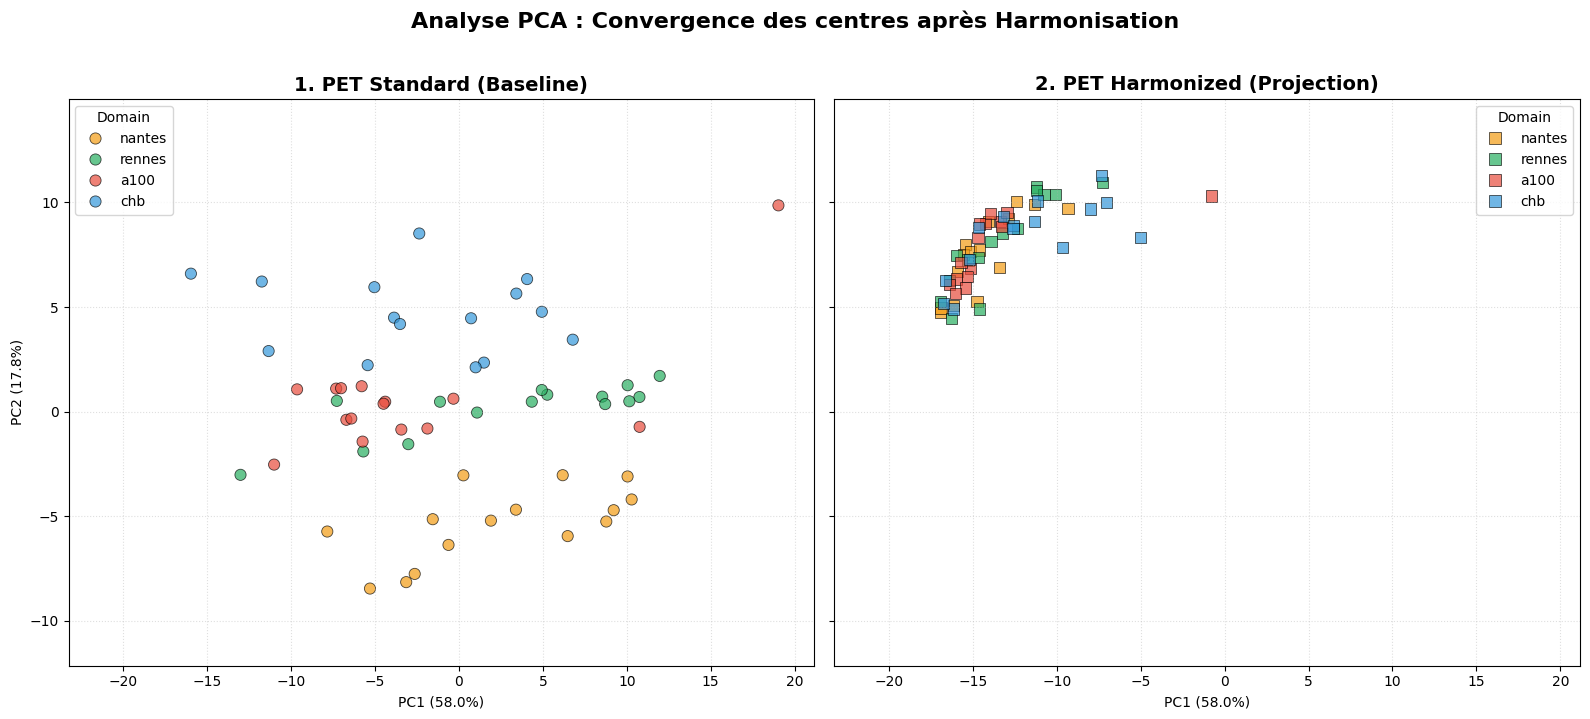

In [30]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

df_std = master_df[master_df['Modality'] == 'pet'].copy()
df_harm = master_df[master_df['Modality'] == 'harmonized-pet-standard-vae'].copy()

display_pca(df_std, df_harm, selected_features)

Nombre de features sélectionnées : 93


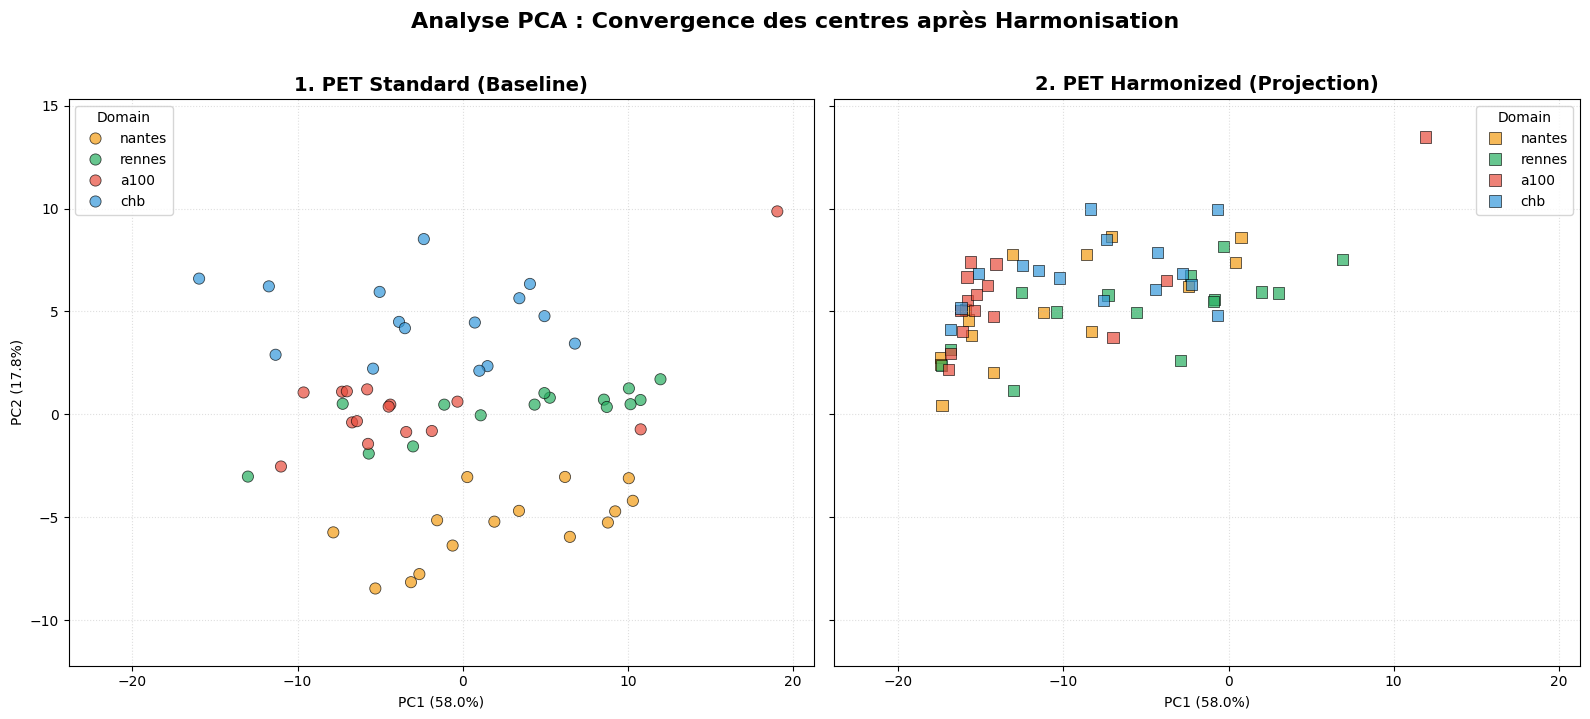

In [31]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

df_std = master_df[master_df['Modality'] == 'pet'].copy()
df_harm = master_df[master_df['Modality'] == 'harmonized-pet-standard-vae'].copy()

display_pca(df_std, df_harm, selected_features)